# 01 · Exploring the Tennessee Eastman process

First-pass look at the dataset before any modelling. Three questions:

1. What do the sensor traces look like under nominal operation?
2. How visible are the 21 fault scenarios?
3. Are the fault classes separable in a low-dimensional projection?

In [1]:
import sensorlab  # set OMP env vars before torch/xgboost load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})


In [2]:
from sensorlab.data import load_dataset, SyntheticTEPConfig
cfg = SyntheticTEPConfig(n_normal_runs=12, n_runs_per_fault=4, fault_run_minutes=480, seed=0)
ds = load_dataset("synthetic", cfg=cfg)
print(f"n_samples={ds.n_samples}  n_sensors={ds.n_sensors}  n_runs={ds.n_runs}")
df = ds.to_dataframe()
df.head()

n_samples=15360  n_sensors=33  n_runs=96


,XMEAS(1),XMEAS(2),XMEAS(3),XMEAS(4),XMEAS(5),XMEAS(6),XMEAS(7),XMEAS(8),XMEAS(9),XMEAS(10),...,XMV(7),XMV(8),XMV(9),XMV(10),XMV(11),fault_id,fault_name,is_anomaly,run_id,t_minutes
0,0.162177,-0.775571,2.032019,-0.044720,1.090408,4.624925,-3.702760,2.374919,0.250648,-0.706994,...,-1.378609,1.695564,0.169420,-2.886226,3.335699,0,Normal,False,0,0.0
1,-0.408013,-0.020883,1.056039,-0.940604,1.112707,2.294723,-3.738557,2.280527,0.895325,-0.984331,...,-0.364271,-1.779364,-0.064198,-3.151521,-0.011046,0,Normal,False,0,3.0
2,-0.189661,0.420602,1.011281,-1.087309,1.291493,2.631288,-4.095860,3.901051,1.645784,-1.738872,...,-0.129078,-2.021452,0.333816,-4.473130,-1.016175,0,Normal,False,0,6.0
3,0.451474,-0.021618,1.044406,-1.130019,0.589319,3.328710,-2.832673,1.907670,1.479198,-1.174625,...,-0.185418,-1.179364,0.724713,-3.492221,0.494902,0,Normal,False,0,9.0
4,-0.579101,0.356060,0.963012,-1.580408,0.926292,2.439645,-3.488682,2.765610,1.662881,-1.184725,...,-0.045194,-3.634606,0.388559,-4.077847,-0.775953,0,Normal,False,0,12.0


## Nominal sensor traces

A single normal run, showing the first 8 sensor channels.

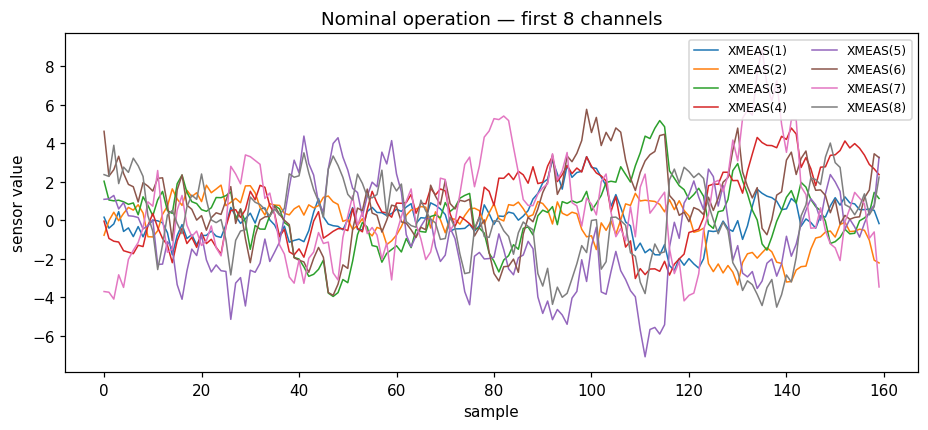

In [3]:
from sensorlab.viz import plot_sensor_traces
normal_run = ds.X[ds.run_id == 0]
ax = plot_sensor_traces(normal_run, ds.sensor_names, sensor_idx=list(range(8)))
ax.set_title("Nominal operation — first 8 channels")
plt.show()

## A fault propagating through the sensor space

Fault 1 (A/C feed ratio step) — note the abrupt regime change around the fault onset (shaded).

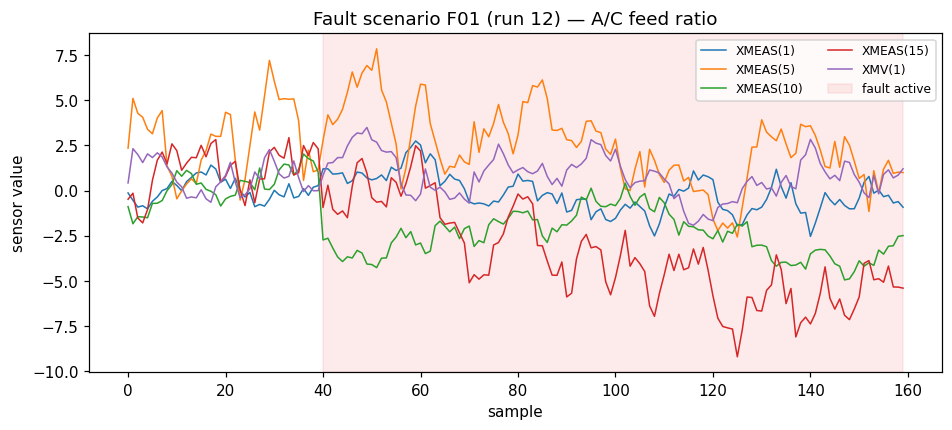

In [4]:
f1_run_id = int(np.where(ds.run_fault_id == 1)[0][0])
mask = ds.run_id == f1_run_id
ax = plot_sensor_traces(ds.X[mask], ds.sensor_names,
                        sensor_idx=[0, 4, 9, 14, 22],
                        is_anomaly=ds.is_anomaly[mask])
ax.set_title(f"Fault scenario F01 (run {f1_run_id}) — A/C feed ratio")
plt.show()

## Are the faults separable?

A 2D PCA on a subset of fault classes — clear clusters means the detectors and classifier downstream have signal to learn from.

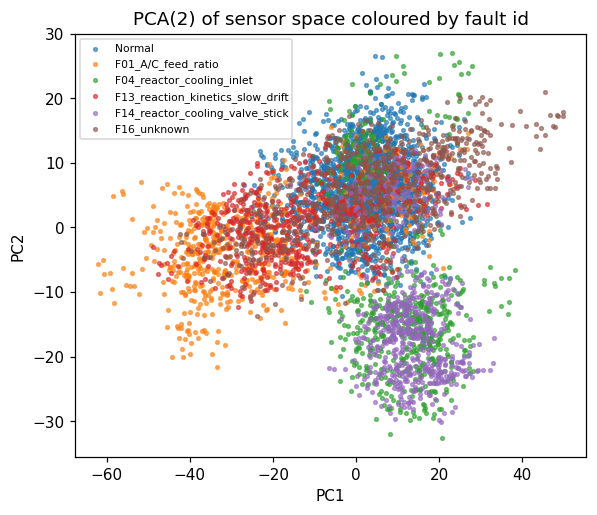

In [5]:
from sensorlab.viz import plot_pca_projection
sample_mask = (ds.fault_id == 0) | np.isin(ds.fault_id, [1, 4, 13, 14, 16])
ax = plot_pca_projection(ds.X[sample_mask], ds.fault_id[sample_mask],
                         label_names=ds.fault_names, max_classes=6)
ax.set_title("PCA(2) of sensor space coloured by fault id")
plt.show()

## Sensor cross-correlation

Process sensors are strongly correlated in continuous chemical plants — exactly why multivariate methods (T²/Q) work and univariate thresholds don't.

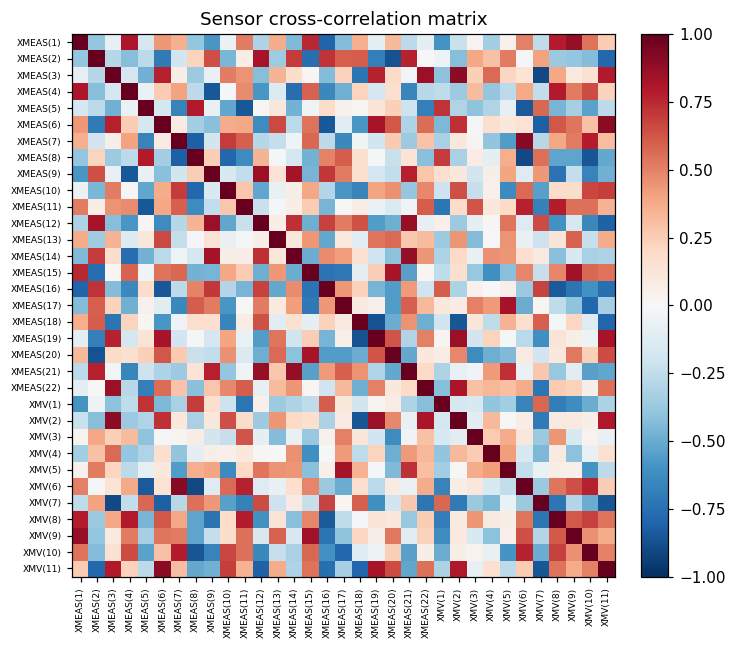

In [6]:
corr = pd.DataFrame(ds.X, columns=ds.sensor_names).corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ds.sensor_names))); ax.set_xticklabels(ds.sensor_names, rotation=90, fontsize=6)
ax.set_yticks(range(len(ds.sensor_names))); ax.set_yticklabels(ds.sensor_names, fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Sensor cross-correlation matrix")
plt.tight_layout(); plt.show()

**Takeaways**

- Sensors share latent structure → multivariate detectors beat per-channel thresholds.
- Step / drift faults shift the mean of several sensors at once (a PCA-T² will fire).
- Variance-only faults (noise increase, intermittent) need either Q-residual or a non-linear model — motivates the LSTM-AE.